# 05 - Comparación final de modelos

## 1. Objetivo

Realizar una comparación final y detallada entre el modelo clásico desarrollado en el Notebook 03, basado en TF-IDF y Regresión Logística, y el modelo Transformer desarrollado en el Notebook 04, basado en DistilBERT con LoRA.

La comparación comprende el análisis de las métricas y figuras persistidas por ambas ramas, así como la evaluación del costo computacional asociado al entrenamiento del Transformer con LoRA en relación con el rendimiento predictivo obtenido.

Este bloque no tiene por finalidad establecer conclusiones a priori sobre la superioridad de una arquitectura respecto de la otra, sino realizar una comparación basada en evidencia experimental. Para preservar su validez, ambos modelos fueron entrenados y evaluados sobre la misma versión histórica del corpus y bajo la misma división de documentos de entrenamiento y prueba.

## 2. Carga de librerías

Se importan únicamente las librerías necesarias para la lectura de los artefactos
persistidos, la gestión de rutas y la construcción de las visualizaciones comparativas.

In [1]:
#============================
# Pandas
#============================

import pandas as pd

#============================
# Numpy
#============================

import numpy as np

#============================
# Scikit-Learn
#============================

from sklearn.metrics import classification_report

#============================
# Matplotlib
#============================

import matplotlib.pyplot as plt

#============================
# Rutas
#============================

from pathlib import Path

# 3. Configuración de rutas y acceso al proyecto

En esta sección se configuran las rutas de salida y se seleccionan los artefactos persistidos pertinentes para la comparación entre ambas ramas.

Sólo se utilizarán aquellos artefactos que cuenten con un equivalente directo en ambas ramas. Este criterio permite realizar una comparación simétrica y directa, evitando inferir resultados a partir de artefactos de distinta naturaleza o disponibilidad.

In [2]:
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Raíz agregada a sys.path:")
print(PROJECT_ROOT)

Raíz agregada a sys.path:
C:\proyecto_nlp_ds3\proyecto_nlp_ds3


## 3.1 Especificación de rutas de artefactos persistidos

In [3]:
from src.paths import (
    PROJECT_ROOT,
    OUTPUTS_TABLES,
    OUTPUTS_FIGURES
)

print("PROJECT_ROOT: ", PROJECT_ROOT)
print("OUTPUTS_TABLES: ", OUTPUTS_TABLES)
print("OUTPUTS_FIGURES: ",  OUTPUTS_FIGURES)

PROJECT_ROOT:  C:\proyecto_nlp_ds3\proyecto_nlp_ds3
OUTPUTS_TABLES:  C:\proyecto_nlp_ds3\proyecto_nlp_ds3\outputs\tables
OUTPUTS_FIGURES:  C:\proyecto_nlp_ds3\proyecto_nlp_ds3\outputs\figures


## 3.2 Listado de archivos persistidos

In [4]:
print("TABLAS:")
for archivo in OUTPUTS_TABLES.iterdir():
    print("-", archivo.name)
    
print()

print("FIGURAS:")
for archivo in OUTPUTS_FIGURES.iterdir():
    print("-", archivo.name)

TABLAS:
- metricas_baseline_tfidf_logistica.csv
- metricas_clases_unificadas.csv
- metricas_globales_unificadas.csv
- metricas_transformer_lora.csv
- metricas_transformer_por_clase_recuperadas.csv
- predicciones_transformer_lora.csv
- top_20_bigramas.csv
- top_20_trigramas.csv
- top_50_palabras.csv

FIGURAS:
- accuracy_curve.png
- comparacion_f1_por_categoria.png
- comparacion_metricas_globales.png
- comparacion_precision_por_categoria.png
- comparacion_recall_por_categoria.png
- confusion_matrix.png
- distribucion_clases.png
- distribucion_longitud_documentos.png
- loss_curve.png
- matriz_confusion_tfidf_logistica.png
- matriz_confusion_transformer_lora.png


## 3.3 Selección de artefactos competentes

In [5]:
metricas_baseline = pd.read_csv(
    OUTPUTS_TABLES / "metricas_baseline_tfidf_logistica.csv")

metricas_transformer = pd.read_csv(
    OUTPUTS_TABLES / "metricas_transformer_lora.csv")

predicciones_transformer = pd.read_csv(
    OUTPUTS_TABLES / "predicciones_transformer_lora.csv")

In [6]:
matriz_baseline = (
    OUTPUTS_FIGURES / "matriz_confusion_tfidf_logistica.png")

matriz_transformer = (
    OUTPUTS_FIGURES / "matriz_confusion_transformer_lora.png")

# 4. Verificación de comparabilidad
Con los artefactos equivalentes generados por ambos modelos ya cargados, se procederá a verificar su estructura, procedencia y condiciones de comparabilidad antes de avanzar hacia la evaluación comparativa de los resultados.

In [7]:
display(metricas_baseline)
display(metricas_transformer)
display(predicciones_transformer)

,Unnamed: 0,precision,recall,f1-score,support
0,Business,0.842829,0.858,0.850347,500.000
1,Sci_Tech,0.874502,0.878,0.876248,500.000
2,Sports,0.948718,0.962,0.955313,500.000
3,World,0.906639,0.874,0.890020,500.000
4,accuracy,0.893000,0.893,0.893000,0.893
5,macro avg,0.893172,0.893,0.892982,2000.000
6,weighted avg,0.893172,0.893,0.892982,2000.000


,metrica,valor
0,accuracy,8.800000e-01
1,precision_macro,8.812932e-01
2,recall_macro,8.800000e-01
3,f1_macro,8.803905e-01
4,tiempo_entrenamiento_segundos,7.858076e+01
5,parametros_totales,6.769767e+07
6,parametros_entrenables,7.411240e+05
7,porcentaje_entrenable,1.094756e+00


,label_real_id,label_pred_id,label_real,label_pred
0,0,2,World,Business
1,2,2,Business,Business
2,1,1,Sports,Sports
3,3,3,Sci_Tech,Sci_Tech
4,1,1,Sports,Sports
...,...,...,...,...
1995,1,1,Sports,Sports
1996,1,1,Sports,Sports
1997,3,3,Sci_Tech,Sci_Tech
1998,1,1,Sports,Sports


In [8]:
print(predicciones_transformer.columns.tolist())
print(predicciones_transformer.shape)

['label_real_id', 'label_pred_id', 'label_real', 'label_pred']
(2000, 4)


## Observaciones sobre la comparabilidad de artefactos

Durante la verificación de los artefactos se detectó que el Notebook 04 persistió las métricas globales del Transformer, pero no una tabla con las métricas desagregadas por categoría. Sin embargo, se encuentran disponibles las predicciones individuales de la ejecución original en `predicciones_transformer_lora.csv`, incluyendo las etiquetas reales y predichas para los 2.000 documentos del conjunto de prueba.

A partir de este artefacto, las métricas por categoría se recalculan mediante `classification_report`, sin reentrenar el modelo ni generar nuevas predicciones. De esta manera, se evita la transcripción manual de valores desde una fuente secundaria y se conserva la trazabilidad respecto de la ejecución original.

Los resultados obtenidos se contrastan con los registrados en el informe técnico `Fernández_Amilcar_Checkpoint_NLP3.pdf` como control de consistencia.

In [9]:
# ==========================================
# Recálculo de métricas por clase - Transformer
# ==========================================

reporte_transformer = classification_report(
    predicciones_transformer["label_real"],
    predicciones_transformer["label_pred"],
    labels=["World", "Sports", "Business", "Sci_Tech"],
    output_dict=True,
    zero_division=0
)

metricas_transformer_clase = (
    pd.DataFrame(reporte_transformer)
    .T
    .loc[["World", "Sports", "Business", "Sci_Tech"]]
    .reset_index()
    .rename(columns={
        "index": "Categoria",
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-Score",
        "support": "Support"
    })
)

display(metricas_transformer_clase)

,Categoria,Precision,Recall,F1-Score,Support
0,World,0.887097,0.88,0.883534,500.0
1,Sports,0.965795,0.96,0.962889,500.0
2,Business,0.795455,0.84,0.817121,500.0
3,Sci_Tech,0.876827,0.84,0.858018,500.0


## 4.1 Integración de métricas por categoría
El objetivo es llevar ambas fuentes a una estructura común que permita compararlas directamente.

In [10]:
# ==========================================
# Normalización de métricas por clase - Baseline
# ==========================================

baseline_clases_normalizado = metricas_baseline.iloc[:4].copy()

baseline_clases_normalizado = (
    baseline_clases_normalizado
    .rename(columns={
        "Unnamed: 0": "Categoria",
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1-Score",
        "support": "Support"
    })
)

baseline_clases_normalizado.insert(
    0,
    "Modelo",
    "TF-IDF + Regresión Logística"
)

display(baseline_clases_normalizado)

,Modelo,Categoria,Precision,Recall,F1-Score,Support
0,TF-IDF + Regresión Logística,Business,0.842829,0.858,0.850347,500.0
1,TF-IDF + Regresión Logística,Sci_Tech,0.874502,0.878,0.876248,500.0
2,TF-IDF + Regresión Logística,Sports,0.948718,0.962,0.955313,500.0
3,TF-IDF + Regresión Logística,World,0.906639,0.874,0.890020,500.0


In [11]:
# ==========================================
# Normalización de métricas por clase - Transformer
# ==========================================

transformer_clases_normalizado = metricas_transformer_clase.copy()

transformer_clases_normalizado.insert(
    0,
    "Modelo",
    "DistilBERT + LoRA"
)

display(transformer_clases_normalizado)

,Modelo,Categoria,Precision,Recall,F1-Score,Support
0,DistilBERT + LoRA,World,0.887097,0.88,0.883534,500.0
1,DistilBERT + LoRA,Sports,0.965795,0.96,0.962889,500.0
2,DistilBERT + LoRA,Business,0.795455,0.84,0.817121,500.0
3,DistilBERT + LoRA,Sci_Tech,0.876827,0.84,0.858018,500.0


In [12]:
# ==========================================
# Integración de métricas por categoría
# ==========================================

metricas_clases_unificadas = pd.concat(
    [
        baseline_clases_normalizado,
        transformer_clases_normalizado
    ],
    ignore_index=True
)

orden_categorias = [
    "World",
    "Sports",
    "Business",
    "Sci_Tech"
]

metricas_clases_unificadas["Categoria"] = pd.Categorical(
    metricas_clases_unificadas["Categoria"],
    categories=orden_categorias,
    ordered=True
)

metricas_clases_unificadas = (
    metricas_clases_unificadas
    .sort_values(["Categoria", "Modelo"])
    .reset_index(drop=True)
)

display(metricas_clases_unificadas)

,Modelo,Categoria,Precision,Recall,F1-Score,Support
0,DistilBERT + LoRA,World,0.887097,0.880,0.883534,500.0
1,TF-IDF + Regresión Logística,World,0.906639,0.874,0.890020,500.0
2,DistilBERT + LoRA,Sports,0.965795,0.960,0.962889,500.0
3,TF-IDF + Regresión Logística,Sports,0.948718,0.962,0.955313,500.0
4,DistilBERT + LoRA,Business,0.795455,0.840,0.817121,500.0
5,TF-IDF + Regresión Logística,Business,0.842829,0.858,0.850347,500.0
6,DistilBERT + LoRA,Sci_Tech,0.876827,0.840,0.858018,500.0
7,TF-IDF + Regresión Logística,Sci_Tech,0.874502,0.878,0.876248,500.0


## Observaciones:

La comparación directa de las métricas por categoría evidencia diferencias acotadas entre ambos modelos, sin una superioridad uniforme de una rama en todas las clases y métricas.

El modelo clásico presenta una ventaja más marcada en Business, tanto en Precision como en Recall y F1-Score. En World, también obtiene mejores resultados en Precision y F1-Score, aunque DistilBERT + LoRA alcanza un Recall ligeramente superior.

En Sports, DistilBERT + LoRA obtiene mayor Precision y F1-Score, mientras que el modelo clásico presenta un Recall levemente superior. En Sci_Tech, el Transformer supera mínimamente al modelo clásico en Precision, mientras que este último obtiene mejores resultados en Recall y F1-Score.

Estas diferencias sugieren un rendimiento competitivo entre ambas ramas, aunque con comportamientos particulares según la categoría y la métrica analizada. La integración posterior de las métricas globales permitirá determinar si estas diferencias se traducen en una ventaja general para alguno de los modelos.

In [13]:
# ==========================================
# Normalización del orden de las categorías
# ==========================================

orden_categorias = [
    "World",
    "Sports",
    "Business",
    "Sci_Tech"
]

metricas_clases_unificadas["Categoria"] = pd.Categorical(
    metricas_clases_unificadas["Categoria"],
    categories=orden_categorias,
    ordered=True
)

metricas_clases_unificadas = (
    metricas_clases_unificadas
    .sort_values(["Modelo", "Categoria"])
    .reset_index(drop=True)
)

display(metricas_clases_unificadas)

,Modelo,Categoria,Precision,Recall,F1-Score,Support
0,DistilBERT + LoRA,World,0.887097,0.880,0.883534,500.0
1,DistilBERT + LoRA,Sports,0.965795,0.960,0.962889,500.0
2,DistilBERT + LoRA,Business,0.795455,0.840,0.817121,500.0
3,DistilBERT + LoRA,Sci_Tech,0.876827,0.840,0.858018,500.0
4,TF-IDF + Regresión Logística,World,0.906639,0.874,0.890020,500.0
5,TF-IDF + Regresión Logística,Sports,0.948718,0.962,0.955313,500.0
6,TF-IDF + Regresión Logística,Business,0.842829,0.858,0.850347,500.0
7,TF-IDF + Regresión Logística,Sci_Tech,0.874502,0.878,0.876248,500.0


## 4.2 Integración de métricas globales para comparación de ramas

In [14]:
# ==========================================
# Extracción de registros de metricas_baseline
# ==========================================

baseline_global = metricas_baseline.iloc[[4,5]].copy()

display(baseline_global)

,Unnamed: 0,precision,recall,f1-score,support
4,accuracy,0.893000,0.893,0.893000,0.893
5,macro avg,0.893172,0.893,0.892982,2000.000


In [15]:
# ==========================================
# Normalización del DataFrame baseline_global
# ==========================================

baseline_global_normalizado = pd.DataFrame({
    "Modelo": ["TF-IDF + Regresión Logística"],
    "Accuracy": [baseline_global.iloc[0]["precision"]],
    "Precision Macro": [baseline_global.iloc[1]["precision"]],
    "Recall Macro": [baseline_global.iloc[1]["recall"]],
    "F1-Score Macro": [baseline_global.iloc[1]["f1-score"]]
})

display(baseline_global_normalizado)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,TF-IDF + Regresión Logística,0.893,0.893172,0.893,0.892982


**Observación:** Para fijar el valor de Accuracy, se decide utilizar el valor almacenado en la columna precision, únicamente por tratarse de la primera columna disponible. Todos los valores de la fila accuracy contienen el mismo valor global repetido, como consecuencia de la estructura con la que fue persistida la tabla original.

In [16]:
# ==========================================
# Extracción de registros de metricas_transformer
# ==========================================

transformer_global = metricas_transformer.iloc[:4].copy()

display(transformer_global)

,metrica,valor
0,accuracy,0.880000
1,precision_macro,0.881293
2,recall_macro,0.880000
3,f1_macro,0.880390


In [17]:
# ==========================================
# Normalización del DataFrame transformer_global
# ==========================================

transformer_global_normalizado = pd.DataFrame({
    "Modelo": ["DistilBERT + LoRA"],
    "Accuracy": [transformer_global.iloc[0]["valor"]],
    "Precision Macro": [transformer_global.iloc[1]["valor"]],
    "Recall Macro": [transformer_global.iloc[2]["valor"]],
    "F1-Score Macro": [transformer_global.iloc[3]["valor"]]
})

display(transformer_global_normalizado)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,DistilBERT + LoRA,0.88,0.881293,0.88,0.88039


In [18]:
# ==========================================
# Integración de ambos DataFrames en metricas_globales_unificadas
# ==========================================

metricas_globales_unificadas = pd.concat(
    [
        baseline_global_normalizado,
        transformer_global_normalizado
    ],
    ignore_index=True
)

display(metricas_globales_unificadas)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,TF-IDF + Regresión Logística,0.893,0.893172,0.893,0.892982
1,DistilBERT + LoRA,0.880,0.881293,0.880,0.880390


## Observaciones:

Las métricas globales evidencian una ligera ventaja del modelo clásico sobre DistilBERT + LoRA en todos los indicadores comparados: Accuracy, Precision Macro, Recall Macro y F1-Score Macro.

En particular, TF-IDF + Regresión Logística alcanza un Accuracy de 89,3 %, frente al 88,0 % obtenido por DistilBERT + LoRA, lo que representa una diferencia de 1,3 puntos porcentuales a favor del baseline.

Este resultado es consistente con la tendencia observada previamente en el análisis por categorías. No obstante, la diferencia global es acotada y, por sí sola, no permite establecer una superioridad general del modelo clásico. La comparación deberá complementarse con el análisis de las matrices de confusión y las restantes dimensiones previstas para la evaluación final.

## 4.3 Verificación final de comparabilidad

In [19]:
# ==========================================
# Verificación estructural de comparabilidad
# ==========================================

print("=== VERIFICACIÓN DE COMPARABILIDAD ===")
print()

print(
    "Cantidad de modelos:",
    metricas_clases_unificadas["Modelo"].nunique()
)

print(
    "Cantidad de categorías:",
    metricas_clases_unificadas["Categoria"].nunique()
)

print(
    "Categorías encontradas:",
    metricas_clases_unificadas["Categoria"].unique().tolist()
)

print(
    "Support uniforme de 500 documentos:",
    (metricas_clases_unificadas["Support"] == 500).all()
)

print(
    "Duplicados Modelo-Categoria:",
    metricas_clases_unificadas.duplicated(
        subset=["Modelo", "Categoria"]
    ).sum()
)

print(
    "Valores nulos en métricas por clase:",
    metricas_clases_unificadas[
        ["Precision", "Recall", "F1-Score", "Support"]
    ].isna().sum().sum()
)

print(
    "Valores nulos en métricas globales:",
    metricas_globales_unificadas[
        ["Accuracy", "Precision Macro", "Recall Macro", "F1-Score Macro"]
    ].isna().sum().sum()
)

=== VERIFICACIÓN DE COMPARABILIDAD ===

Cantidad de modelos: 2
Cantidad de categorías: 4
Categorías encontradas: ['World', 'Sports', 'Business', 'Sci_Tech']
Support uniforme de 500 documentos: True
Duplicados Modelo-Categoria: 0
Valores nulos en métricas por clase: 0
Valores nulos en métricas globales: 0


# 5. Comparación visual entre ambos modelos

## 5.1 Comparación visual de métricas globales

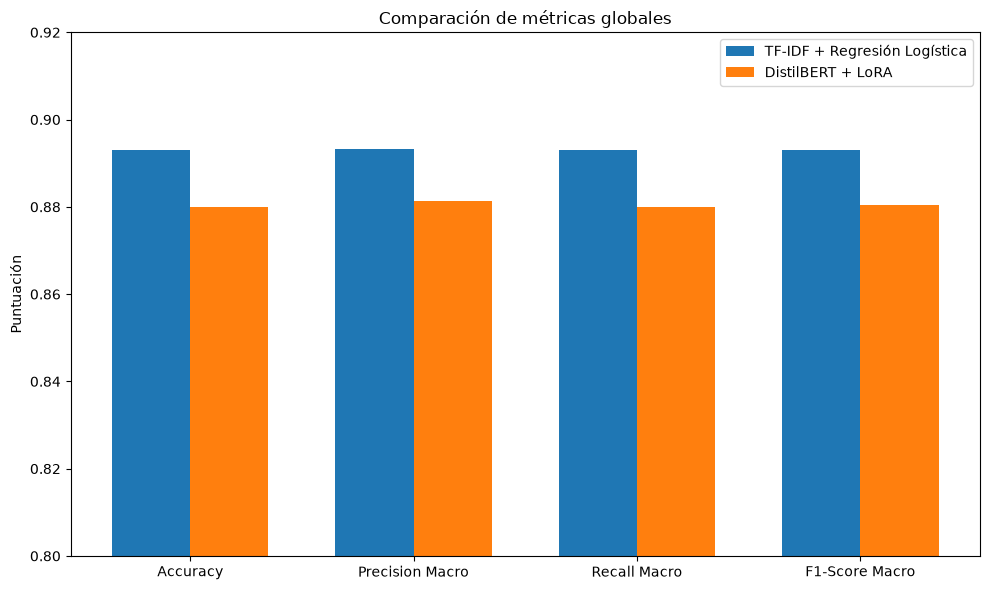

In [20]:
# ==========================================
# Comparación visual de métricas globales
# ==========================================

metricas = [
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1-Score Macro"
]

valores_baseline = (
    metricas_globales_unificadas
    .iloc[0][metricas]
    .astype(float)
    .values
)

valores_transformer = (
    metricas_globales_unificadas
    .iloc[1][metricas]
    .astype(float)
    .values
)

x = np.arange(len(metricas))
ancho = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho / 2,
    valores_baseline,
    ancho,
    label="TF-IDF + Regresión Logística"
)

plt.bar(
    x + ancho / 2,
    valores_transformer,
    ancho,
    label="DistilBERT + LoRA"
)

plt.xticks(x, metricas)
plt.ylabel("Puntuación")
plt.title("Comparación de métricas globales")
plt.ylim(0.80, 0.92)
plt.legend()

plt.tight_layout()
plt.show()

## Observaciones:

Como se evidenció previamente en el análisis de la tabla integrada, el modelo clásico obtiene resultados superiores a DistilBERT + LoRA en las cuatro métricas globales comparadas. La diferencia se mantiene estable entre los indicadores y se refleja finalmente en un Accuracy de 89,3 % para TF-IDF + Regresión Logística, frente al 88,0 % obtenido por el modelo Transformer.

La escala del eje vertical se limita al intervalo 0,80–0,92 para facilitar la observación de diferencias pequeñas entre ambos modelos, por lo que la magnitud visual de la separación debe interpretarse considerando dicha escala.

## 5.2 Comparación visual de métricas por categoría.

In [21]:
# ==========================================
# Preparación de datos para comparación por categoría
# ==========================================

categorias = ["World", "Sports", "Business", "Sci_Tech"]

baseline_clases_grafico = metricas_clases_unificadas[
    metricas_clases_unificadas["Modelo"] == "TF-IDF + Regresión Logística"
]

transformer_clases_grafico = metricas_clases_unificadas[
    metricas_clases_unificadas["Modelo"] == "DistilBERT + LoRA"
]

x = np.arange(len(categorias))
ancho = 0.35

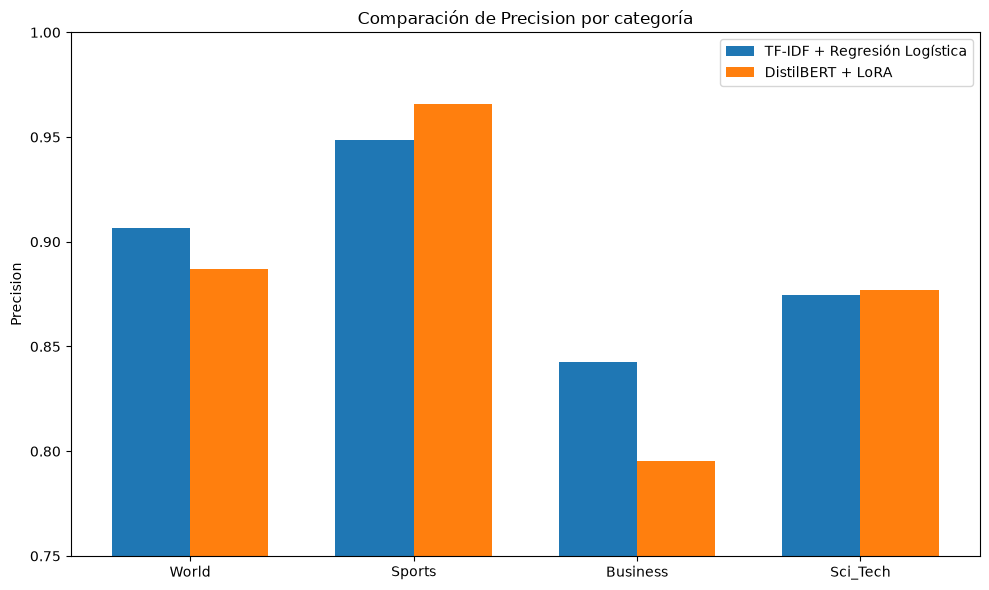

In [22]:
# ==========================================
# Comparación de Precision por categoría
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho / 2,
    baseline_clases_grafico["Precision"],
    ancho,
    label="TF-IDF + Regresión Logística"
)

plt.bar(
    x + ancho / 2,
    transformer_clases_grafico["Precision"],
    ancho,
    label="DistilBERT + LoRA"
)

plt.xticks(x, categorias)
plt.ylabel("Precision")
plt.title("Comparación de Precision por categoría")
plt.ylim(0.75, 1.00)
plt.legend()

plt.tight_layout()
plt.show()

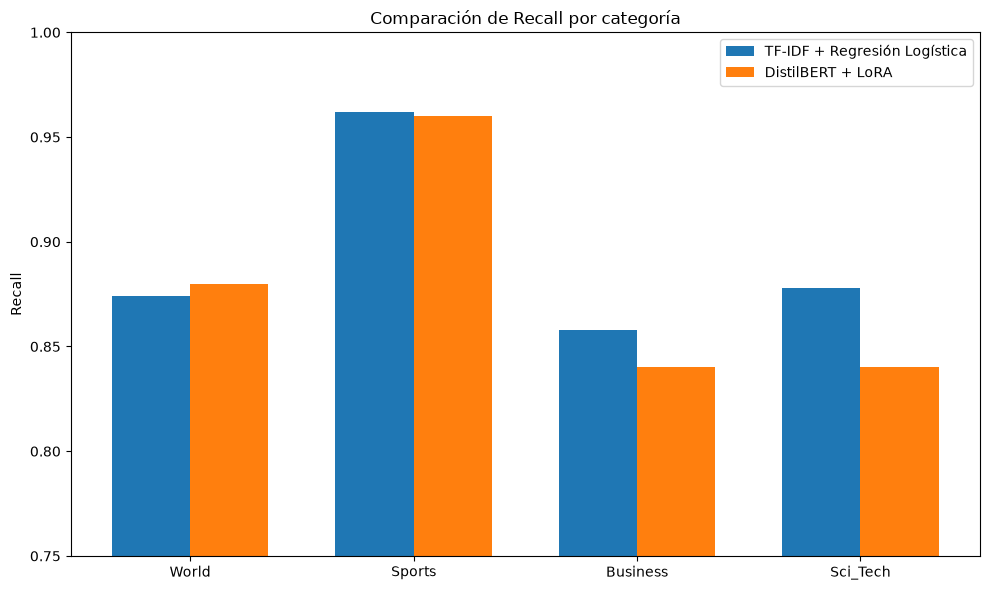

In [23]:
# ==========================================
# Comparación de Recall por categoría
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho / 2,
    baseline_clases_grafico["Recall"],
    ancho,
    label="TF-IDF + Regresión Logística"
)

plt.bar(
    x + ancho / 2,
    transformer_clases_grafico["Recall"],
    ancho,
    label="DistilBERT + LoRA"
)

plt.xticks(x, categorias)
plt.ylabel("Recall")
plt.title("Comparación de Recall por categoría")
plt.ylim(0.75, 1.00)
plt.legend()

plt.tight_layout()
plt.show()

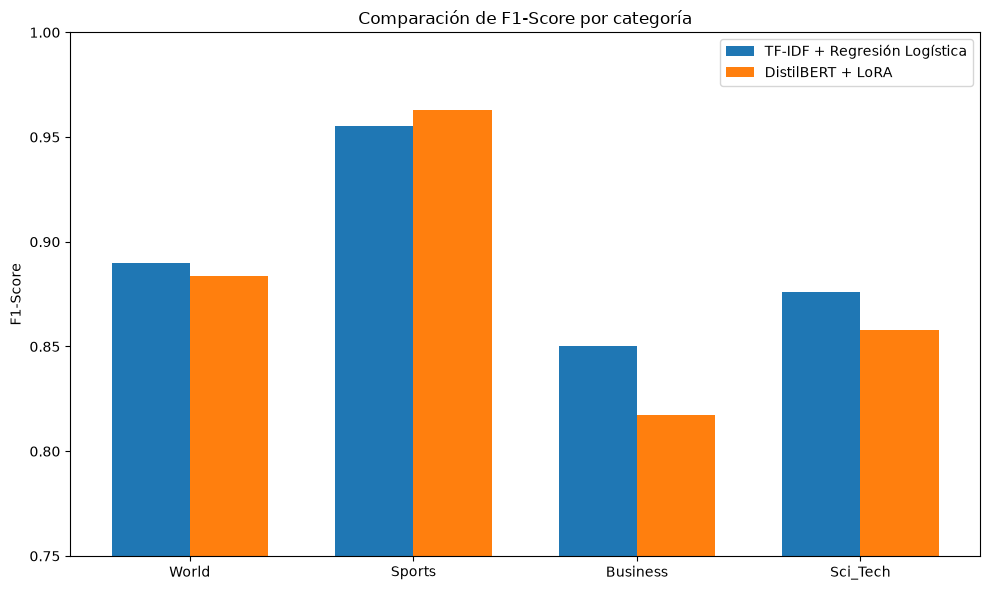

In [24]:
# ==========================================
# Comparación de F1-Score por categoría
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    x - ancho / 2,
    baseline_clases_grafico["F1-Score"],
    ancho,
    label="TF-IDF + Regresión Logística"
)

plt.bar(
    x + ancho / 2,
    transformer_clases_grafico["F1-Score"],
    ancho,
    label="DistilBERT + LoRA"
)

plt.xticks(x, categorias)
plt.ylabel("F1-Score")
plt.title("Comparación de F1-Score por categoría")
plt.ylim(0.75, 1.00)
plt.legend()

plt.tight_layout()
plt.show()

## Observaciones

La comparación visual por categoría confirma que las diferencias entre ambos modelos no son uniformes y dependen tanto de la clase como de la métrica evaluada.

En World, el modelo clásico obtiene mayor Precision y F1-Score, mientras que DistilBERT + LoRA presenta un Recall ligeramente superior. En Sports, ambos modelos alcanzan sus mejores resultados: el Transformer obtiene mayor Precision y F1-Score, mientras que el baseline presenta una ventaja mínima en Recall.

La diferencia más marcada se observa en Business, donde TF-IDF + Regresión Logística supera al Transformer en Precision, Recall y F1-Score. En Sci_Tech, DistilBERT + LoRA presenta una Precision apenas superior, pero el modelo clásico obtiene mejores resultados en Recall y F1-Score.

En conjunto, las figuras respaldan lo observado previamente en las tablas comparativas: el Transformer presenta ventajas puntuales, especialmente en Sports, mientras que el modelo clásico muestra un comportamiento más favorable en el balance general de las categorías. La escala vertical se limita al intervalo 0,75–1,00 para facilitar la visualización de diferencias entre modelos.

## 5.3 Comparación de matrices de confusión

In [25]:
# ==========================================
# Identificación de matrices persistidas
# ==========================================

figuras_matrices = [
    archivo
    for archivo in OUTPUTS_FIGURES.iterdir()
    if "confusion" in archivo.name.lower()
]

for archivo in figuras_matrices:
    print(archivo.name)

confusion_matrix.png
matriz_confusion_tfidf_logistica.png
matriz_confusion_transformer_lora.png


In [26]:
# ==========================================
# Carga de matrices de confusión persistidas
# ==========================================

ruta_matriz_baseline = OUTPUTS_FIGURES / "matriz_confusion_tfidf_logistica.png"
ruta_matriz_transformer = OUTPUTS_FIGURES / "matriz_confusion_transformer_lora.png"

matriz_baseline = plt.imread(ruta_matriz_baseline)
matriz_transformer = plt.imread(ruta_matriz_transformer)

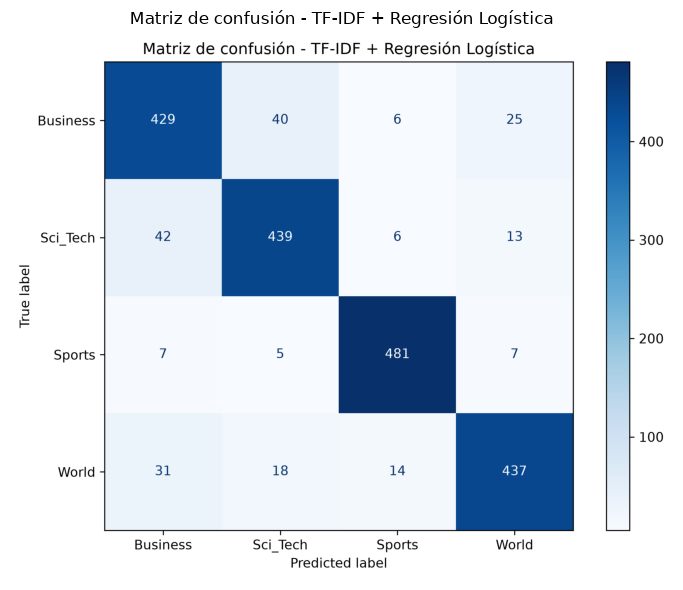

In [27]:
# ==========================================
# Matriz de confusión - Baseline
# ==========================================

plt.figure(figsize=(8, 6))
plt.imshow(matriz_baseline)
plt.axis("off")
plt.title("Matriz de confusión - TF-IDF + Regresión Logística")
plt.tight_layout()
plt.show()

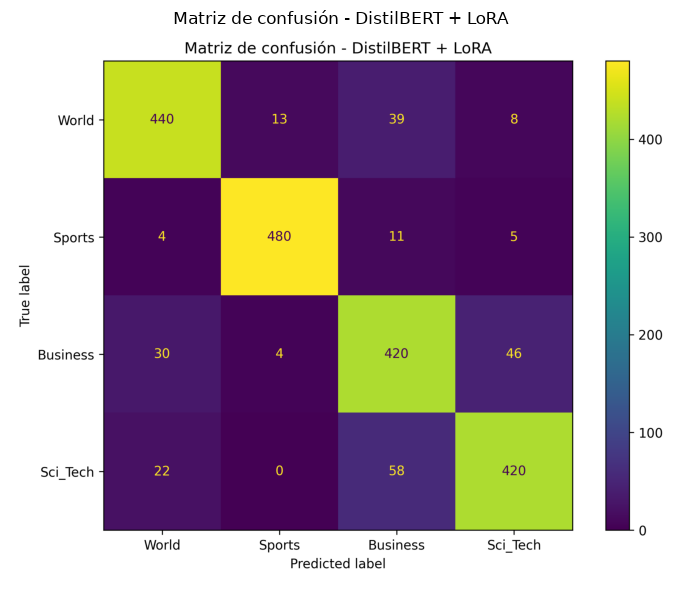

In [28]:
# ==========================================
# Matriz de confusión - Transformer
# ==========================================

plt.figure(figsize=(8, 6))
plt.imshow(matriz_transformer)
plt.axis("off")
plt.title("Matriz de confusión - DistilBERT + LoRA")
plt.tight_layout()
plt.show()

## Observaciones

Los aciertos por categoría del baseline se obtienen directamente de la diagonal principal de la matriz de confusión persistida por el Notebook 03; dado que cada categoría contiene 500 documentos, estos valores son además consistentes con los respectivos valores de Recall × 500.

Las matrices de confusión confirman que ambos modelos concentran la mayor parte de sus predicciones sobre la diagonal principal, en concordancia con los niveles elevados de Accuracy observados previamente.

Sports constituye la categoría de mejor desempeño en ambas ramas, con 481 clasificaciones correctas para TF-IDF + Regresión Logística y 480 para DistilBERT + LoRA.

Las diferencias más relevantes aparecen en Business y Sci_Tech. El modelo clásico clasifica correctamente 429 documentos Business y 439 Sci_Tech, mientras que el Transformer alcanza 420 aciertos en cada una. En este último se observa especialmente una confusión de 58 documentos Sci_Tech clasificados como Business, además de 46 documentos Business clasificados como Sci_Tech.

En World, ambos modelos presentan resultados similares: 437 clasificaciones correctas para el baseline y 440 para el Transformer. Sin embargo, la distribución de sus errores difiere, destacándose en el Transformer 39 documentos World clasificados como Business.

En conjunto, las matrices permiten observar que la ventaja global del modelo clásico no proviene de una superioridad uniforme sobre todas las categorías, sino principalmente de un mejor comportamiento en Business y Sci_Tech, mientras que ambos modelos presentan desempeños muy similares en Sports y World.

## 5.4 Análisis de desacuerdos entre modelos

Limitación para el análisis de desacuerdos entre modelos

El análisis documento a documento de los desacuerdos entre ambas ramas requiere disponer de las predicciones individuales generadas por cada modelo sobre el mismo conjunto de prueba.

La rama Transformer persistió las etiquetas reales y predichas de su ejecución original en predicciones_transformer_lora.csv. Sin embargo, el Notebook 03 no persistió un artefacto equivalente para TF-IDF + Regresión Logística, ni conservó el modelo entrenado y el vectorizador ajustado necesarios para reproducir posteriormente la etapa de inferencia.

Si bien el baseline clásico presenta un proceso de entrenamiento más estable y podría ser reejecutado bajo la misma configuración, una nueva ejecución constituiría una reconstrucción posterior y no permitiría garantizar que las predicciones obtenidas correspondan exactamente a las de la ejecución histórica evaluada.

Por este motivo, se decide no reconstruir retrospectivamente las predicciones del baseline y no realizar una comparación documento a documento sobre evidencia generada en momentos diferentes. La ausencia de este artefacto se documenta como una limitación de persistencia del experimento original.

Para futuras iteraciones y expansiones del proyecto, se establece como requisito persistir las predicciones individuales de todas las ramas evaluadas, incluyendo como mínimo la etiqueta real, la etiqueta predicha y un identificador que permita vincular cada predicción con el documento correspondiente.

# 6. Comparación de coste y eficiencia computacional

## Consideraciones sobre la comparabilidad del coste computacional

La comparación directa del coste computacional entre ambas ramas presenta una limitación de trazabilidad. El Notebook 04 persistió información correspondiente al tiempo de entrenamiento, cantidad total de parámetros, parámetros entrenables y porcentaje de parámetros entrenables del modelo Transformer. Sin embargo, el Notebook 03 no persistió métricas computacionales equivalentes para el baseline TF-IDF + Regresión Logística.

Debido a esta diferencia entre los artefactos disponibles, no se realizará una comparación cuantitativa directa del coste de entrenamiento entre ambos modelos ni se volverán a ejecutar entrenamientos anteriores con el único propósito de reconstruir información no persistida.

En consecuencia, esta sección se limitará a caracterizar el coste computacional registrado para DistilBERT + LoRA y el efecto de LoRA sobre la proporción de parámetros entrenables. Esta limitación será considerada posteriormente al formular las conclusiones comparativas del proyecto.

## 6.1 Caracterización del coste computacional del Transformer

In [29]:
# ==========================================
# Extracción de métricas computacionales
# ==========================================

metricas_computacionales_transformer = (
    metricas_transformer
    .iloc[4:]
    .copy()
    .reset_index(drop=True)
)

display(metricas_computacionales_transformer)

,metrica,valor
0,tiempo_entrenamiento_segundos,7.858076e+01
1,parametros_totales,6.769767e+07
2,parametros_entrenables,7.411240e+05
3,porcentaje_entrenable,1.094756e+00


## Observaciones

El entrenamiento de DistilBERT + LoRA registró un tiempo de aproximadamente 78,6 segundos. El modelo cuenta con aproximadamente 67,7 millones de parámetros totales, de los cuales 741.124 fueron entrenables, equivalentes al 1,09 % del total.

La baja proporción de parámetros entrenables evidencia el efecto de LoRA como estrategia de ajuste eficiente: la mayor parte de los parámetros del modelo preentrenado permaneció congelada durante el entrenamiento, mientras que una fracción reducida fue ajustada para la tarea específica de clasificación.

Estos resultados permiten caracterizar el coste de la rama Transformer, aunque no establecer una diferencia cuantitativa respecto del baseline debido a la ausencia de métricas computacionales equivalentes persistidas para dicha rama.

# 7. Síntesis comparativa final

## 7.1 Tabla de síntesis

| Dimensión | TF-IDF + Regresión Logística | DistilBERT + LoRA |
|---|---|---|
| Accuracy | 89,3 % | 88,0 % |
| Precision Macro | 0,8932 | 0,8813 |
| Recall Macro | 0,8930 | 0,8800 |
| F1-Score Macro | 0,8930 | 0,8804 |
| Mejor desempeño por clase | Sports | Sports |
| Principal dificultad | Business | Business / Sci_Tech |
| Tiempo de entrenamiento | No persistido | 78,6 s |
| Parámetros totales | No comparable / no persistido | 67,7 millones |
| Parámetros entrenables | No comparable / no persistido | 741.124 (1,09 %) |

## 7.2 Interpretación integrada

## Observaciones

La evidencia integrada muestra que TF-IDF + Regresión Logística obtuvo el mejor rendimiento predictivo global bajo las condiciones experimentales definidas para el proyecto. El baseline supera a DistilBERT + LoRA en Accuracy, Precision Macro, Recall Macro y F1-Score Macro, aunque las diferencias globales son acotadas. La diferencia de Accuracy es de 1,3 puntos porcentuales a favor del modelo clásico.

El análisis desagregado muestra que esta ventaja no es uniforme. Ambos modelos presentan su mejor desempeño en Sports, mientras que Business constituye la categoría de menor F1-Score en ambas ramas. DistilBERT + LoRA obtiene ventajas puntuales en algunas combinaciones de clase y métrica, pero estas no se traducen en una mejora del rendimiento global.

Las matrices de confusión complementan esta lectura y muestran que una parte relevante de la diferencia entre modelos se concentra en el tratamiento de Business y Sci_Tech. El Transformer presenta una confusión particularmente visible entre ambas categorías, mientras que el baseline consigue una mayor cantidad de clasificaciones correctas en ellas.

Respecto del coste computacional, DistilBERT + LoRA requirió el ajuste de 741.124 parámetros, equivalentes al 1,09 % de aproximadamente 67,7 millones de parámetros totales, con un tiempo de entrenamiento registrado de 78,6 segundos. La ausencia de métricas computacionales equivalentes persistidas para el baseline impide establecer una comparación cuantitativa directa de eficiencia entre ambas ramas.

Por lo tanto, los resultados permiten concluir que el aumento de complejidad arquitectónica no produjo, en este experimento, una mejora del rendimiento predictivo respecto del baseline clásico. Esta conclusión se restringe a la configuración, corpus y condiciones experimentales evaluadas y no implica una superioridad general de la Regresión Logística frente a los modelos Transformer.

# 8. Persistencia de artefactos comparativos

In [30]:
# ==========================================
# Persistencia de tablas comparativas
# ==========================================

metricas_clases_unificadas.to_csv(
    OUTPUTS_TABLES / "metricas_clases_unificadas.csv",
    index=False
)

metricas_globales_unificadas.to_csv(
    OUTPUTS_TABLES / "metricas_globales_unificadas.csv",
    index=False
)

print("Tablas comparativas persistidas correctamente.")

Tablas comparativas persistidas correctamente.


In [31]:
# ==========================================
# Comparación visual de métricas globales
# ==========================================

metricas = [
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1-Score Macro"
]

valores_baseline = (
    metricas_globales_unificadas
    .iloc[0][metricas]
    .astype(float)
    .values
)

valores_transformer = (
    metricas_globales_unificadas
    .iloc[1][metricas]
    .astype(float)
    .values
)

x = np.arange(len(metricas))
ancho = 0.35

# Creación explícita de Figure y Axes
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - ancho / 2,
    valores_baseline,
    ancho,
    label="TF-IDF + Regresión Logística"
)

ax.bar(
    x + ancho / 2,
    valores_transformer,
    ancho,
    label="DistilBERT + LoRA"
)

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel("Puntuación")
ax.set_title("Comparación de métricas globales")
ax.set_ylim(0.80, 0.92)
ax.legend()

fig.tight_layout()

# Persistencia de la figura específica
fig.savefig(
    OUTPUTS_FIGURES / "comparacion_metricas_globales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("Figura de métricas globales exportada correctamente.")

Figura de métricas globales exportada correctamente.


In [32]:
# ==========================================
# Comparación de Precision por categoría
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - ancho / 2,
    baseline_clases_grafico["Precision"],
    ancho,
    label="TF-IDF + Regresión Logística"
)

ax.bar(
    x + ancho / 2,
    transformer_clases_grafico["Precision"],
    ancho,
    label="DistilBERT + LoRA"
)

ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylabel("Precision")
ax.set_title("Comparación de Precision por categoría")
ax.set_ylim(0.75, 1.00)
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUTS_FIGURES / "comparacion_precision_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("Figura de Precision por categoría exportada correctamente.")

Figura de Precision por categoría exportada correctamente.


In [33]:
# ==========================================
# Comparación de Recall por categoría
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - ancho / 2,
    baseline_clases_grafico["Recall"],
    ancho,
    label="TF-IDF + Regresión Logística"
)

ax.bar(
    x + ancho / 2,
    transformer_clases_grafico["Recall"],
    ancho,
    label="DistilBERT + LoRA"
)

ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylabel("Recall")
ax.set_title("Comparación de Recall por categoría")
ax.set_ylim(0.75, 1.00)
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUTS_FIGURES / "comparacion_recall_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("Figura de Recall por categoría exportada correctamente.")

Figura de Recall por categoría exportada correctamente.


In [34]:
# ==========================================
# Comparación de F1-Score por categoría
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - ancho / 2,
    baseline_clases_grafico["F1-Score"],
    ancho,
    label="TF-IDF + Regresión Logística"
)

ax.bar(
    x + ancho / 2,
    transformer_clases_grafico["F1-Score"],
    ancho,
    label="DistilBERT + LoRA"
)

ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylabel("F1-Score")
ax.set_title("Comparación de F1-Score por categoría")
ax.set_ylim(0.75, 1.00)
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUTS_FIGURES / "comparacion_f1_por_categoria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("Figura de F1-Score por categoría exportada correctamente.")

Figura de F1-Score por categoría exportada correctamente.


# 9. Conclusión

La comparación final permitió evaluar ambas ramas bajo las mismas condiciones experimentales, utilizando los artefactos persistidos durante sus ejecuciones originales y las métricas derivadas reproduciblemente a partir de ellos.

TF-IDF + Regresión Logística obtuvo el mayor rendimiento predictivo global, con un Accuracy de 89,3 %, frente al 88,0 % alcanzado por DistilBERT + LoRA. La misma tendencia se mantuvo en Precision Macro, Recall Macro y F1-Score Macro, aunque el análisis por categoría mostró diferencias puntuales entre ambos modelos y confirmó que la ventaja del baseline no fue uniforme en todas las clases y métricas.

Las matrices de confusión permitieron localizar parte de esta diferencia principalmente en las categorías Business y Sci_Tech, mientras que Sports presentó el mejor desempeño para ambas ramas.

La caracterización computacional del Transformer mostró que LoRA permitió limitar el entrenamiento a aproximadamente el 1,09 % de los parámetros totales. Sin embargo, la ausencia de métricas computacionales equivalentes persistidas para el baseline impide realizar una comparación cuantitativa directa de eficiencia entre ambas arquitecturas.

Bajo las condiciones evaluadas, el incremento de complejidad introducido por DistilBERT + LoRA no produjo una mejora del rendimiento predictivo respecto del baseline clásico. Este resultado corresponde exclusivamente al corpus, configuración y procedimiento experimental utilizados y no implica una superioridad general de una arquitectura sobre la otra.